In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df= pd.read_csv(r'/home/fatima/Desktop/SOFTGROWTECH_INTERNSHIP_FINAL_PROJECT/Interactive_DashBoards/dash.csv')

In [4]:
# info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.value_counts()

Age  Attrition  BusinessTravel     DailyRate  Department              DistanceFromHome  Education  EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  JobRole                    JobSatisfaction  MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked  Over18  OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
41   Yes        Travel_Rarely      1102       Sales                   1                 2          Life Sciences   1              1               2                        Female  94          3               2         Sales Executive            4                Single         5993           19479        8                   Y       Yes       11                 3                  1                         80            

In [7]:
# find out unique values of employee count
df.loc[:,['EmployeeCount']]

,EmployeeCount
0,1
1,1
2,1
3,1
4,1
...,...
1465,1
1466,1
1467,1
1468,1


In [8]:
df.groupby('Attrition')['EmployeeCount'].count()

Attrition
No     1233
Yes     237
Name: EmployeeCount, dtype: int64

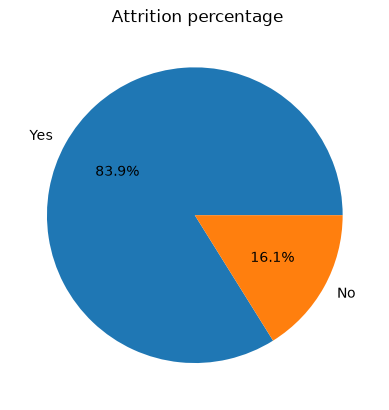

<Figure size 600x300 with 0 Axes>

In [9]:
#find the Attrition distribution 
df.groupby(df['Attrition'])['EmployeeCount'].count().plot(kind='pie',autopct='%1.1f%%',labels=['Yes','No'])
plt.title(' Attrition percentage')
plt.figure(figsize=(6,3))
plt.show()


In [10]:
# find the percentage of attrition
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Attrition Overview')

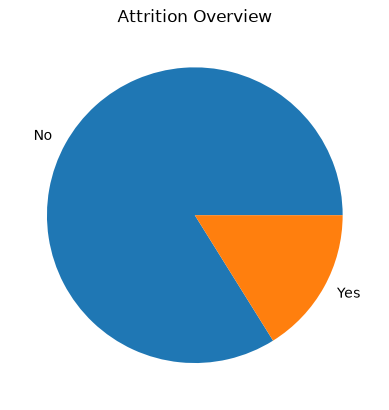

In [11]:
df.groupby(df['Attrition'])['EmployeeCount'].count().plot(kind='pie')
plt.title('Attrition Overview')

In [12]:
# attrition by department
df.groupby('Department')['Attrition'].count()

Department
Human Resources            63
Research & Development    961
Sales                     446
Name: Attrition, dtype: int64

In [13]:
df.pivot_table(index=df['Department'],columns=df['Attrition'],values=['EmployeeCount'],aggfunc='count')

EmployeeCount     
Attrition                         No  Yes
Department                               
Human Resources                   51   12
Research & Development           828  133
Sales                            354   92

In [14]:
# create a new table
df['Attrition%'] = (df['Attrition']=='yes').astype(int)

In [21]:
# percantage 
df.groupby(['Department','Attrition'])['Attrition%'].count().sort_values(ascending=False)

Department              Attrition
Research & Development  No           828
Sales                   No           354
Research & Development  Yes          133
Sales                   Yes           92
Human Resources         No            51
                        Yes           12
Name: Attrition%, dtype: int64

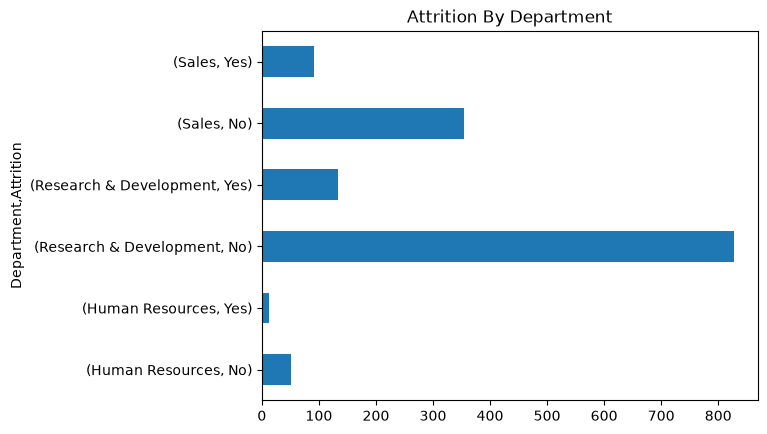

In [20]:
# piechart
df.groupby(['Department','Attrition'])['Attrition%'].count().plot(kind='barh')
plt.title('Attrition By Department')
plt.show()

In [ ]:
# age distribution
df.groupby(['Age'])['Attrition'].value_counts()

Age  Attrition
18   No            4
     Yes           4
19   Yes           6
     No            3
20   Yes           6
                  ..
57   No            4
58   No            9
     Yes           5
59   No           10
60   No            5
Name: count, Length: 82, dtype: int64

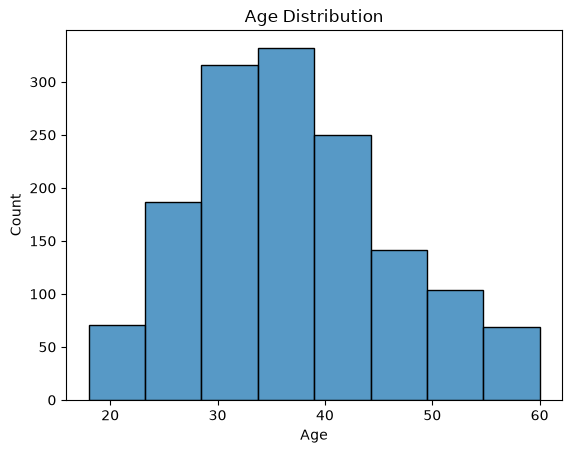

In [28]:
sb.histplot(x=df['Age'],bins=8)
plt.title('Age Distribution')
plt.show()

In [31]:
print(df['Age'].std())
print(df['Age'].max())
print(df['Age'].min())
print(df['Age'].mean())
print(df['Age'].median())

9.135373489136732
60
18
36.923809523809524
36.0


In [37]:
# attrition by age group
df.groupby(['Age','Attrition'])['Attrition%'].count()

Age  Attrition
18   No            4
     Yes           4
19   No            3
     Yes           6
20   No            5
                  ..
57   No            4
58   No            9
     Yes           5
59   No           10
60   No            5
Name: Attrition%, Length: 82, dtype: int64

In [40]:
#average monthly income by department
df.groupby(['Department'])['MonthlyIncome'].mean().sort_values(ascending=False)

Department
Sales                     6959.172646
Human Resources           6654.507937
Research & Development    6281.252862
Name: MonthlyIncome, dtype: float64

In [41]:
# Attrition by job roles
df.groupby(['JobRole'])['EmployeeCount'].count()

JobRole
Healthcare Representative    131
Human Resources               52
Laboratory Technician        259
Manager                      102
Manufacturing Director       145
Research Director             80
Research Scientist           292
Sales Executive              326
Sales Representative          83
Name: EmployeeCount, dtype: int64

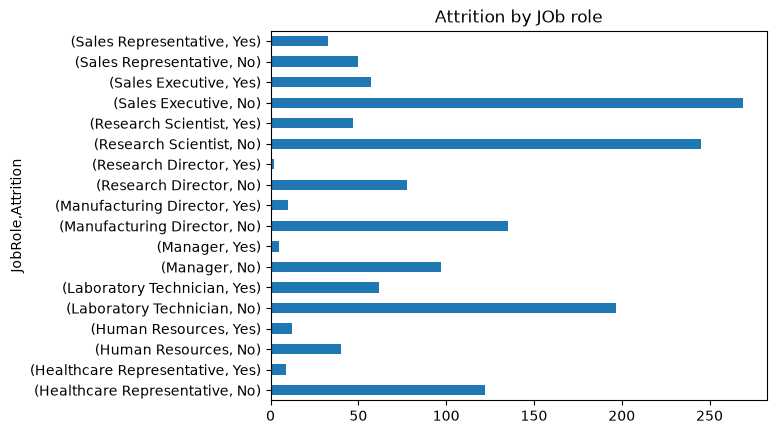

In [43]:
df.groupby(['JobRole','Attrition'])['EmployeeCount'].count().plot(kind='barh')
plt.title('Attrition by JOb role')
plt.show()

In [45]:



df.groupby(['JobRole'])['Attrition%'].count().sort_values(ascending=False)

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: Attrition%, dtype: int64